# Space Risk IA — Sistema inteligente de alerta com dados espaciais simulados
### Global Solution · 1º semestre de 2026 · IA & Machine Learning · Desafio FIAP: Indústria Espacial

**Integrantes:**
- Lucca Borges — RM 554608
- Ruan Melo — RM 557599
- Rodrigo Jimenez — RM 558148
- João Victor Franco — RM 556790
- Bruno Leão — RM 555563

**Turma:** 3ESPZ

---

## Resumo da solução
Protótipo de IA que apoia **defesa civil, agricultura e gestão ambiental** a partir de dados de
regiões monitoradas por satélite (simulados). A plataforma responde a **três perguntas**:

1. **Qual o índice de impacto estimado** de uma região? → *regressão linear múltipla*
2. **A região é de baixo ou alto risco?** → *regressão logística* e *árvore de decisão*
3. **Existem grupos naturais de regiões com perfis parecidos?** → *K-Means*

### Conexão com o briefing da economia espacial
A nova economia espacial não é só foguetes e satélites: ela permite **monitorar o planeta,
prevenir desastres e apoiar decisões estratégicas**. Aqui usamos variáveis típicas de
sensoriamento remoto (NDVI de vegetação, temperatura, umidade do solo, chuva prevista,
cobertura de nuvens) para antecipar regiões em risco.

### ODS da ONU atendidos
- **ODS 2 — Fome zero e agricultura sustentável** *(principal)*: NDVI, umidade do solo e chuva
  permitem identificar regiões agrícolas ameaçadas por seca ou perda de vegetação.
- **ODS 13 — Ação contra a mudança do clima**: as variáveis modeladas (chuva extrema, vento,
  temperatura) estão diretamente ligadas a eventos climáticos extremos.
- **ODS 9 — Indústria, inovação e infraestrutura** *(transversal)*: a própria solução é IA +
  dados espaciais aplicados a um problema de impacto social.


## Setup — bibliotecas e carregamento do dataset

In [1]:
# Bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import (r2_score, mean_absolute_error, accuracy_score,
                             confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score)

%matplotlib inline
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42  # garante resultados reprodutíveis

In [2]:
# Carregar o CSV.
# No Google Colab, descomente as 3 linhas do bloco de upload.
# Localmente (ou após o upload), lê o arquivo direto.
ARQ = "dataset_space_risk_global_solution.csv"

try:
    from google.colab import files          # só existe no Colab
    import os
    if not os.path.exists(ARQ):
        print("Faça o upload do arquivo:", ARQ)
        up = files.upload()
        ARQ = list(up.keys())[0]
except ImportError:
    pass  # fora do Colab: usa o arquivo local

df = pd.read_csv(ARQ)
print("Dataset carregado:", df.shape[0], "regiões x", df.shape[1], "colunas")

Dataset carregado: 320 regiões x 14 colunas


## Etapa 1 — Carregar e compreender os dados

In [3]:
# Primeiras linhas
df.head()

,regiao_id,temperatura_media_c,umidade_solo_pct,indice_vegetacao_ndvi,chuva_prevista_mm,vento_kmh,proximidade_area_urbana_km,historico_eventos_5anos,altitude_m,inclinacao_terreno_graus,densidade_populacional_km2,cobertura_nuvens_pct,indice_impacto,risco_alto
0,R168,27.2,82.6,0.343,100.8,29.7,19.0,1,77.9,6.3,1875.9,66.6,64.9,1
1,R231,27.1,75.7,0.457,86.0,22.2,0.5,3,67.4,5.9,1304.8,61.4,62.5,1
2,R026,20.0,66.3,0.595,13.9,16.6,55.8,1,468.7,5.2,229.7,64.6,10.3,0
3,R064,26.6,41.9,0.708,40.7,9.4,28.2,2,648.4,10.5,139.7,68.7,38.6,0
4,R010,27.8,63.8,0.608,24.2,16.1,59.5,0,477.1,9.4,37.3,33.0,14.6,0


In [4]:
# Dimensões, tipos e estatísticas
print("Linhas x Colunas:", df.shape)
print("\nValores nulos por coluna:", df.isnull().sum().sum(), "(total)")
print("Linhas duplicadas:", df.duplicated().sum())
df.info()

Linhas x Colunas: (320, 14)

Valores nulos por coluna: 0 (total)
Linhas duplicadas: 0
<class 'pandas.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   regiao_id                   320 non-null    str    
 1   temperatura_media_c         320 non-null    float64
 2   umidade_solo_pct            320 non-null    float64
 3   indice_vegetacao_ndvi       320 non-null    float64
 4   chuva_prevista_mm           320 non-null    float64
 5   vento_kmh                   320 non-null    float64
 6   proximidade_area_urbana_km  320 non-null    float64
 7   historico_eventos_5anos     320 non-null    int64  
 8   altitude_m                  320 non-null    float64
 9   inclinacao_terreno_graus    320 non-null    float64
 10  densidade_populacional_km2  320 non-null    float64
 11  cobertura_nuvens_pct        320 non-null    float64
 12  indice_impacto   

In [5]:
df.describe().round(2)

,temperatura_media_c,umidade_solo_pct,indice_vegetacao_ndvi,chuva_prevista_mm,vento_kmh,proximidade_area_urbana_km,historico_eventos_5anos,altitude_m,inclinacao_terreno_graus,densidade_populacional_km2,cobertura_nuvens_pct,indice_impacto,risco_alto
count,320.00,320.00,320.00,320.00,320.00,320.00,320.00,320.00,320.00,320.00,320.00,320.00,320.00
mean,27.69,56.41,0.48,44.33,21.86,24.55,3.61,474.55,10.69,584.16,48.94,56.38,0.62
std,5.72,23.19,0.18,34.87,9.16,21.64,2.22,320.07,10.32,634.60,24.23,24.70,0.48
min,15.30,5.00,0.05,0.00,3.70,0.50,0.00,0.00,0.00,5.00,0.00,0.00,0.00
25%,23.65,40.02,0.34,10.28,14.90,7.60,2.00,175.35,3.80,124.00,29.18,42.50,0.00
50%,26.30,63.05,0.50,40.25,21.00,16.80,3.00,458.80,6.60,290.40,49.65,64.95,1.00
75%,30.62,72.93,0.62,72.65,28.45,39.55,5.00,714.72,13.77,905.65,68.22,73.90,1.00
max,45.00,95.70,0.86,155.80,46.40,90.00,10.00,1413.90,45.00,2662.10,100.00,96.80,1.00


### Respostas obrigatórias da Etapa 1
1. **Quantas regiões existem no dataset?** → **320 regiões** (320 linhas, 14 colunas). Sem nulos e sem duplicatas.
2. **Qual coluna é o target da regressão?** → `indice_impacto` (variável numérica contínua a ser prevista).
3. **Qual coluna é o target da classificação?** → `risco_alto` (0 = baixo risco, 1 = alto risco).
4. **Por que `regiao_id` não deve ser usado no treino?** → É apenas um **identificador** (rótulo `R001`,
   `R002`…). Não carrega informação ambiental e não tem relação causal com o risco; usá-lo como feature
   só faria o modelo "decorar" IDs (memorização/overfitting), sem capacidade de generalizar para regiões novas.

**Features (entradas)** = 11 variáveis ambientais/operacionais · **Targets (saídas)** = `indice_impacto` (regressão) e `risco_alto` (classificação).


## Etapa 2 — Análise exploratória e correlação

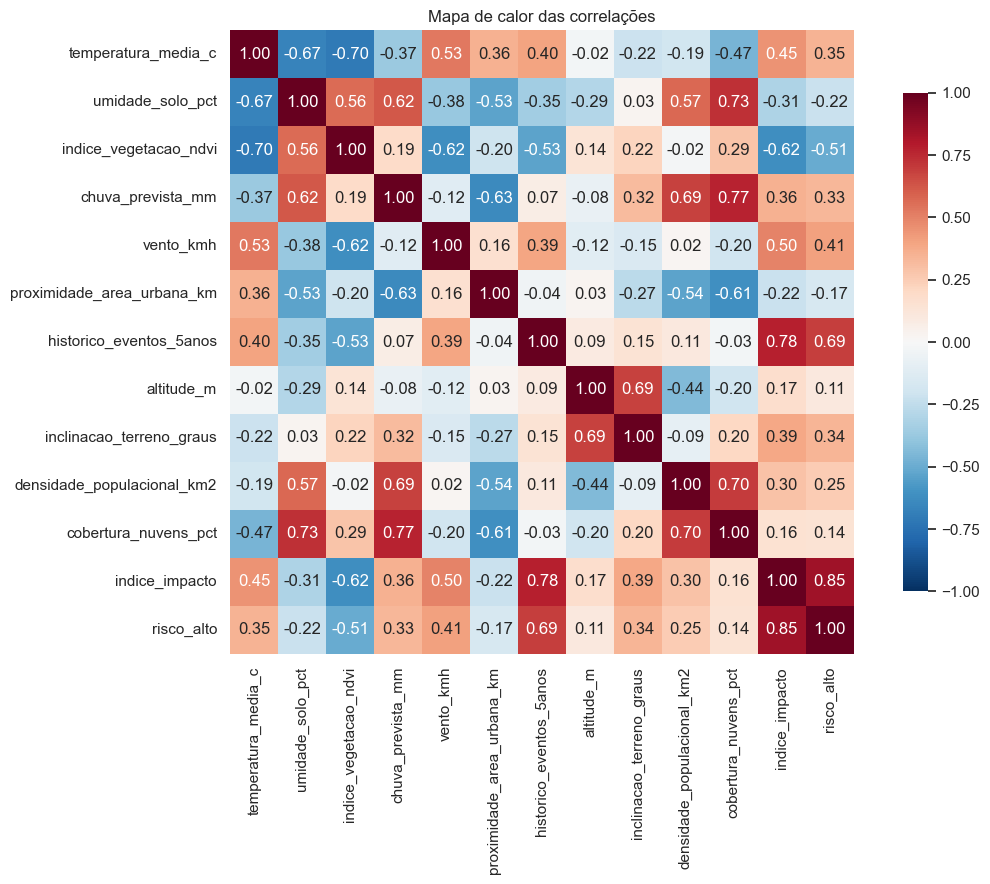

In [6]:
# Matriz de correlação (sem o identificador regiao_id)
corr = df.drop(columns=["regiao_id"]).corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8})
plt.title("Mapa de calor das correlações")
plt.tight_layout()
plt.show()

In [7]:
# Variáveis mais associadas a cada target
print("Correlação com indice_impacto (regressão):")
print(corr["indice_impacto"].drop(["indice_impacto"]).sort_values(ascending=False).round(3))
print("\nCorrelação com risco_alto (classificação):")
print(corr["risco_alto"].drop(["risco_alto"]).sort_values(ascending=False).round(3))

Correlação com indice_impacto (regressão):
risco_alto                    0.846
historico_eventos_5anos       0.776
vento_kmh                     0.496
temperatura_media_c           0.453
inclinacao_terreno_graus      0.388
chuva_prevista_mm             0.358
densidade_populacional_km2    0.295
altitude_m                    0.173
cobertura_nuvens_pct          0.156
proximidade_area_urbana_km   -0.220
umidade_solo_pct             -0.309
indice_vegetacao_ndvi        -0.619
Name: indice_impacto, dtype: float64

Correlação com risco_alto (classificação):
indice_impacto                0.846
historico_eventos_5anos       0.693
vento_kmh                     0.409
temperatura_media_c           0.346
inclinacao_terreno_graus      0.341
chuva_prevista_mm             0.333
densidade_populacional_km2    0.253
cobertura_nuvens_pct          0.141
altitude_m                    0.106
proximidade_area_urbana_km   -0.166
umidade_solo_pct             -0.224
indice_vegetacao_ndvi        -0.507
Name: risco_

### Interpretação da correlação (5–8 linhas)
O `indice_impacto` e o `risco_alto` estão fortemente correlacionados entre si (~0,85), o que é
esperado: regiões de maior impacto tendem a ser de alto risco. Entre as variáveis ambientais, o
**`indice_vegetacao_ndvi` tem a correlação negativa mais forte** (≈ −0,62 com o impacto e −0,51 com
o risco): **quanto mais verde a região, menor o risco**. Já `historico_eventos_5anos` (≈ +0,78),
`vento_kmh`, `temperatura_media_c`, `inclinacao_terreno_graus` e `chuva_prevista_mm` puxam o risco
**para cima**. `umidade_solo_pct` e `proximidade_area_urbana_km` têm correlação negativa moderada.
**Correlação não prova causa**: esses números só orientam a escolha inicial de variáveis e ajudam
a justificar a leitura dos resultados dos modelos.


## Etapa 3 — Regressão linear múltipla (prever `indice_impacto`)

In [8]:
# Features: tudo, menos o identificador e os DOIS targets
X_reg = df.drop(columns=["regiao_id", "indice_impacto", "risco_alto"])
y_reg = df["indice_impacto"]

Xtr, Xte, ytr, yte = train_test_split(X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)

lin = LinearRegression().fit(Xtr, ytr)
pred = lin.predict(Xte)

r2 = r2_score(yte, pred)
mae = mean_absolute_error(yte, pred)
print(f"R²  = {r2:.3f}")
print(f"MAE = {mae:.2f}  (erro médio em pontos do índice, que vai de 0 a ~97)")

R²  = 0.974
MAE = 3.23  (erro médio em pontos do índice, que vai de 0 a ~97)


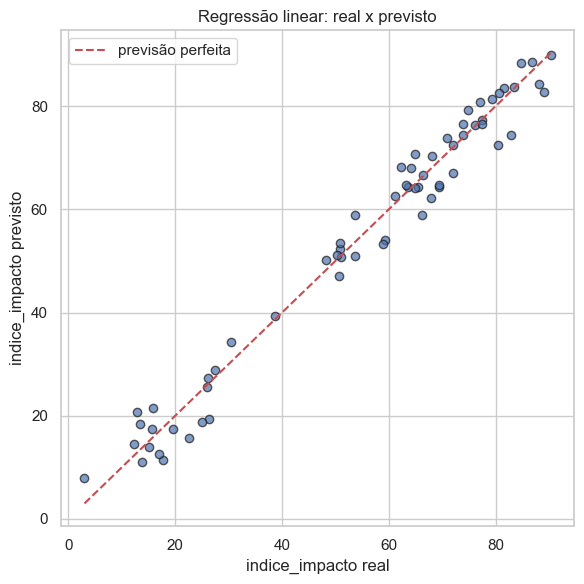

In [9]:
# Valor real x previsto
plt.figure(figsize=(6, 6))
plt.scatter(yte, pred, alpha=0.7, edgecolor="k")
lims = [min(yte.min(), pred.min()), max(yte.max(), pred.max())]
plt.plot(lims, lims, "r--", label="previsão perfeita")
plt.xlabel("indice_impacto real"); plt.ylabel("indice_impacto previsto")
plt.title("Regressão linear: real x previsto"); plt.legend(); plt.tight_layout(); plt.show()

In [10]:
# Peso de cada variável (coeficientes)
coef = pd.Series(lin.coef_, index=X_reg.columns).sort_values(key=abs, ascending=False)
coef.round(3).to_frame("coeficiente")

,coeficiente
indice_vegetacao_ndvi,-36.519
historico_eventos_5anos,3.717
inclinacao_terreno_graus,0.847
temperatura_media_c,0.707
vento_kmh,0.317
umidade_solo_pct,-0.310
chuva_prevista_mm,0.217
cobertura_nuvens_pct,0.097
proximidade_area_urbana_km,-0.058
densidade_populacional_km2,0.007


### Interpretação da regressão linear
O modelo atingiu **R² ≈ 0,97** e **MAE ≈ 3,2 pontos**. Um **R² alto sugere que as variáveis ambientais
e operacionais explicam muito bem o `indice_impacto`** — ou seja, o índice é quase reconstruível a
partir das condições da região (vegetação, histórico de eventos, vento, temperatura, chuva etc.). O
MAE de ~3 pontos, numa escala que vai de 0 a ~97, mostra erro pequeno na prática. Os coeficientes
confirmam a leitura da correlação: NDVI puxa o índice **para baixo**, enquanto histórico de eventos,
vento e temperatura puxam **para cima**.


## Etapa 4 — Classificação com regressão logística (prever `risco_alto`)

In [11]:
# IMPORTANTE: NÃO usar indice_impacto como feature aqui (evita vazamento de resposta)
X_clf = df.drop(columns=["regiao_id", "indice_impacto", "risco_alto"])
y_clf = df["risco_alto"]

Xtr, Xte, ytr, yte = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf)  # estratificado

logit = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
]).fit(Xtr, ytr)

pred_lr = logit.predict(Xte)
print(f"Acurácia = {accuracy_score(yte, pred_lr):.3f}\n")
print("Relatório de classificação:")
print(classification_report(yte, pred_lr, target_names=["baixo risco (0)", "alto risco (1)"]))

Acurácia = 0.938

Relatório de classificação:
                 precision    recall  f1-score   support

baixo risco (0)       0.95      0.88      0.91        24
 alto risco (1)       0.93      0.97      0.95        40

       accuracy                           0.94        64
      macro avg       0.94      0.93      0.93        64
   weighted avg       0.94      0.94      0.94        64



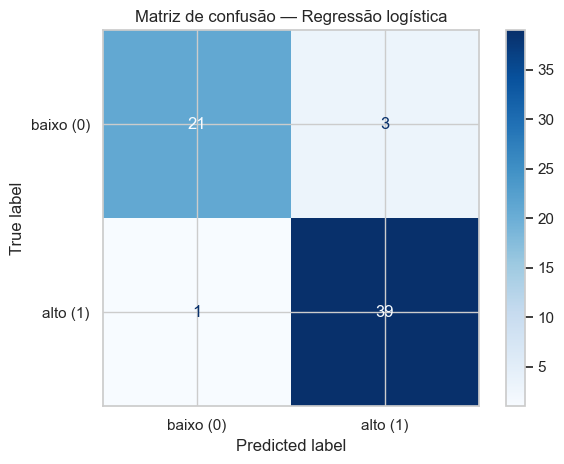

In [12]:
# Matriz de confusão
ConfusionMatrixDisplay.from_predictions(
    yte, pred_lr, display_labels=["baixo (0)", "alto (1)"], cmap="Blues")
plt.title("Matriz de confusão — Regressão logística"); plt.tight_layout(); plt.show()

In [13]:
# Probabilidade estimada de ALTO risco (predict_proba) — 8 regiões de exemplo
proba = logit.predict_proba(Xte)[:, 1]
amostra = pd.DataFrame({
    "regiao_id": df.loc[Xte.index, "regiao_id"].values,
    "prob_alto_risco": proba.round(3),
    "previsto": pred_lr,
    "real": yte.values,
}).sort_values("prob_alto_risco", ascending=False)
amostra.head(8)

,regiao_id,prob_alto_risco,previsto,real
59,R274,1.000,1,1
39,R259,1.000,1,1
6,R222,0.999,1,1
22,R316,0.999,1,1
43,R121,0.999,1,1
8,R102,0.998,1,1
5,R292,0.998,1,1
12,R290,0.996,1,1


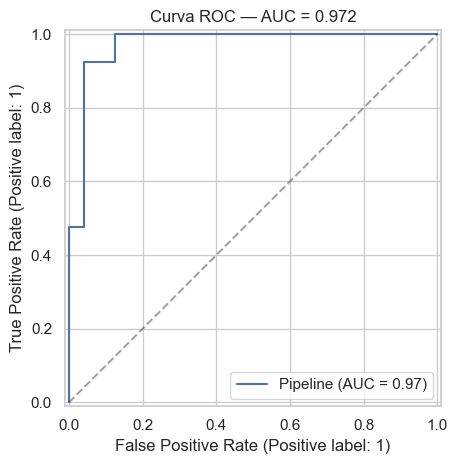

In [14]:
# (Reforço) Curva ROC e AUC
RocCurveDisplay.from_estimator(logit, Xte, yte)
plt.plot([0, 1], [0, 1], "k--", alpha=.4)
plt.title(f"Curva ROC — AUC = {roc_auc_score(yte, proba):.3f}")
plt.tight_layout(); plt.show()

### Respostas obrigatórias da Etapa 4
1. **O que significa uma região com probabilidade próxima de 1 para `risco_alto`?** → O modelo está
   **muito confiante** de que aquela região é de alto risco; combinada com as features, ela se parece
   fortemente com os casos historicamente classificados como críticos. Num sistema de alerta, essas
   regiões iriam para o topo da fila de atenção da defesa civil.
2. **A matriz de confusão mostrou mais falso positivo ou falso negativo?** → **Mais falso positivo (≈3)
   do que falso negativo (≈1)**. Ou seja, o modelo erra mais "para o lado seguro": às vezes acende o
   alerta numa região que era de baixo risco.
3. **Qual erro é mais perigoso num sistema de alerta?** → O **falso negativo** (classificar uma região
   de **alto** risco como **baixo**). Esse erro faz a defesa civil **não agir** numa área que precisava
   de atenção, podendo custar vidas e safras. O falso positivo apenas gera um custo de verificação. Por
   isso, num alerta real, priorizaríamos **recall da classe de alto risco** — e é bom que aqui o falso
   negativo já seja o erro mais raro.


## Etapa 5 — Classificação com árvore de decisão

In [15]:
# Mesmo X e y da regressão logística
tree = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE).fit(Xtr, ytr)
pred_dt = tree.predict(Xte)
print(f"Acurácia (árvore) = {accuracy_score(yte, pred_dt):.3f}")
print(f"Acurácia (logística, p/ comparação) = {accuracy_score(yte, pred_lr):.3f}")

Acurácia (árvore) = 0.969
Acurácia (logística, p/ comparação) = 0.938


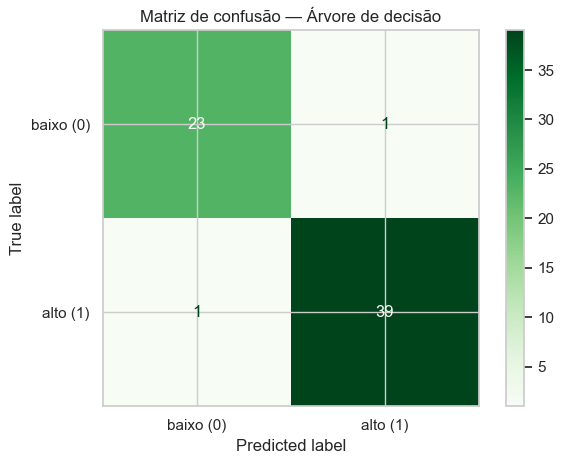

In [16]:
ConfusionMatrixDisplay.from_predictions(
    yte, pred_dt, display_labels=["baixo (0)", "alto (1)"], cmap="Greens")
plt.title("Matriz de confusão — Árvore de decisão"); plt.tight_layout(); plt.show()

In [17]:
# Regras em texto (interpretável)
print(export_text(tree, feature_names=list(X_clf.columns)))

|--- historico_eventos_5anos <= 2.50
|   |--- chuva_prevista_mm <= 49.05
|   |   |--- indice_vegetacao_ndvi <= 0.30
|   |   |   |--- class: 1
|   |   |--- indice_vegetacao_ndvi >  0.30
|   |   |   |--- inclinacao_terreno_graus <= 34.15
|   |   |   |   |--- class: 0
|   |   |   |--- inclinacao_terreno_graus >  34.15
|   |   |   |   |--- class: 1
|   |--- chuva_prevista_mm >  49.05
|   |   |--- proximidade_area_urbana_km <= 3.75
|   |   |   |--- vento_kmh <= 9.05
|   |   |   |   |--- class: 1
|   |   |   |--- vento_kmh >  9.05
|   |   |   |   |--- class: 0
|   |   |--- proximidade_area_urbana_km >  3.75
|   |   |   |--- cobertura_nuvens_pct <= 45.55
|   |   |   |   |--- class: 0
|   |   |   |--- cobertura_nuvens_pct >  45.55
|   |   |   |   |--- class: 1
|--- historico_eventos_5anos >  2.50
|   |--- historico_eventos_5anos <= 3.50
|   |   |--- chuva_prevista_mm <= 77.70
|   |   |   |--- inclinacao_terreno_graus <= 21.80
|   |   |   |   |--- class: 0
|   |   |   |--- inclinacao_terreno_gr

Importância das variáveis na árvore:
 historico_eventos_5anos       0.594
chuva_prevista_mm             0.160
inclinacao_terreno_graus      0.107
proximidade_area_urbana_km    0.049
indice_vegetacao_ndvi         0.046
cobertura_nuvens_pct          0.028
vento_kmh                     0.016
umidade_solo_pct              0.000
temperatura_media_c           0.000
altitude_m                    0.000
densidade_populacional_km2    0.000
dtype: float64 



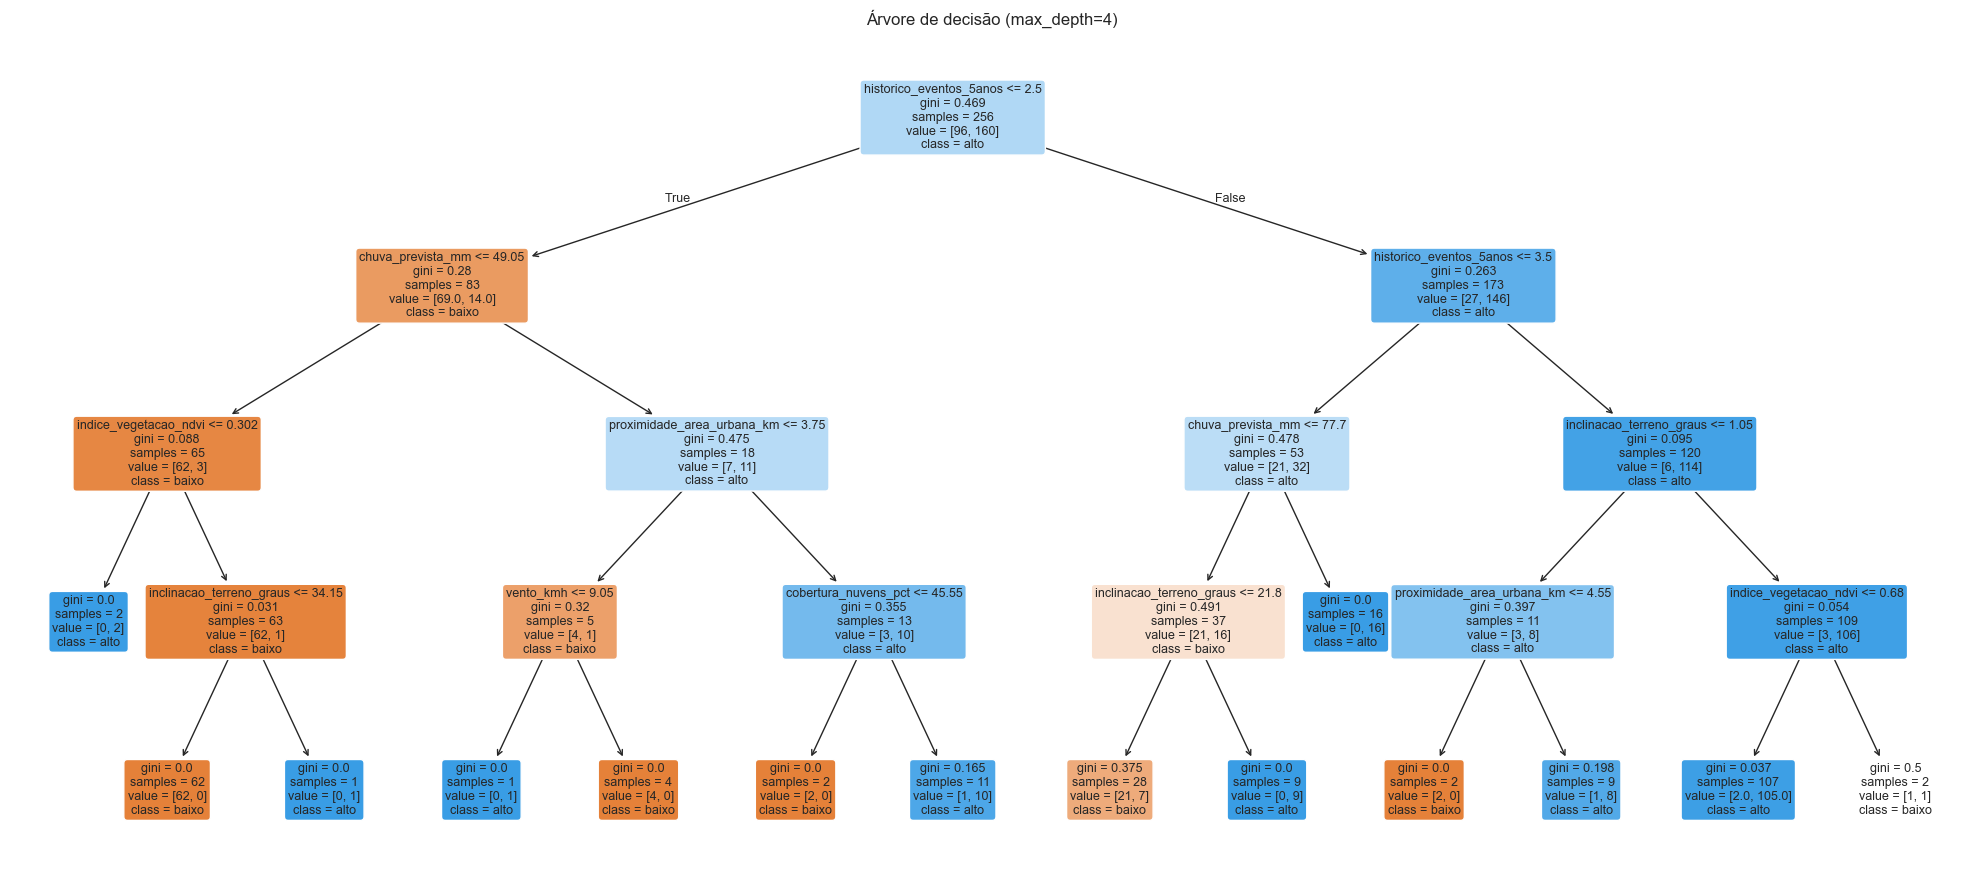

In [18]:
# (Reforço) Importância das variáveis + desenho da árvore
imp = pd.Series(tree.feature_importances_, index=X_clf.columns).sort_values(ascending=False)
print("Importância das variáveis na árvore:\n", imp.round(3), "\n")

plt.figure(figsize=(20, 9))
plot_tree(tree, feature_names=list(X_clf.columns),
          class_names=["baixo", "alto"], filled=True, rounded=True, fontsize=9)
plt.title("Árvore de decisão (max_depth=4)"); plt.tight_layout(); plt.show()

### Interpretação da árvore e comparação com a logística
A árvore (max_depth=4) chegou a **acurácia ≈ 0,97**, ligeiramente acima da logística (≈ 0,94), com
**menos falsos positivos**. Sua grande vantagem é a **explicabilidade**: o `export_text` mostra regras
do tipo *"se `historico_eventos_5anos` ≤ X e `indice_vegetacao_ndvi` > Y → baixo risco"*, que **qualquer
pessoa não técnica consegue ler e auditar** — diferente da logística, que entrega coeficientes/pesos
mais abstratos. Em contrapartida, a logística entrega **probabilidades calibradas** (via `predict_proba`),
úteis para priorizar alertas. As duas concordam sobre quais variáveis mais importam (NDVI e histórico de
eventos lideram a importância).


### Validação cruzada (robustez dos classificadores)
Para confirmar que os resultados não dependem de um único sorteio de treino/teste, rodamos uma **validação cruzada estratificada (5-fold)** com os dois classificadores, sobre todo o conjunto de dados.

In [19]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_lr = cross_val_score(logit, X_clf, y_clf, cv=cv, scoring="accuracy")
cv_dt = cross_val_score(DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
                        X_clf, y_clf, cv=cv, scoring="accuracy")
print("Validação cruzada (5-fold) — acurácia média ± desvio:")
print(f"  Regressão logística: {cv_lr.mean():.3f} ± {cv_lr.std():.3f}")
print(f"  Árvore de decisão:   {cv_dt.mean():.3f} ± {cv_dt.std():.3f}")

Validação cruzada (5-fold) — acurácia média ± desvio:
  Regressão logística: 0.928 ± 0.038
  Árvore de decisão:   0.878 ± 0.044


**Interpretação:** a validação cruzada confirma a estabilidade da **logística (~0,93 ± 0,04)**. A árvore cai para **~0,88 ± 0,04** — ou seja, a acurácia de 0,97 no split único foi um pouco **otimista**, e a logística **generaliza de forma mais consistente**. Isso reforça usá-la como modelo principal do alerta, com a árvore no papel de explicação das regras.

## Etapa 6 — Segmentação com K-Means (sem usar o target)

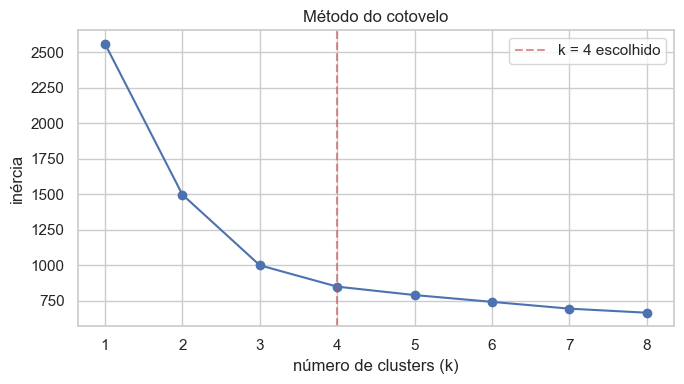

In [20]:
# Variáveis ambientais para agrupar — NUNCA usar risco_alto nem indice_impacto
feat_cluster = ["temperatura_media_c", "umidade_solo_pct", "indice_vegetacao_ndvi",
                "chuva_prevista_mm", "vento_kmh", "densidade_populacional_km2",
                "proximidade_area_urbana_km", "historico_eventos_5anos"]

Z = StandardScaler().fit_transform(df[feat_cluster])  # padroniza (K-Means usa distância)

# (Reforço) Método do cotovelo para justificar k=4
inertias = [KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Z).inertia_
            for k in range(1, 9)]
plt.figure(figsize=(7, 4))
plt.plot(range(1, 9), inertias, "o-")
plt.axvline(4, color="r", ls="--", alpha=.6, label="k = 4 escolhido")
plt.xlabel("número de clusters (k)"); plt.ylabel("inércia")
plt.title("Método do cotovelo"); plt.legend(); plt.tight_layout(); plt.show()

In [21]:
# Treina o K-Means com k = 4
km = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10).fit(Z)
df["cluster"] = km.labels_
print("Tamanho de cada cluster:")
print(df["cluster"].value_counts().sort_index())

Tamanho de cada cluster:
cluster
0    77
1    80
2    83
3    80
Name: count, dtype: int64


In [22]:
# Perfil médio de cada cluster (incluímos risco/impacto só para LER os grupos, não para treinar)
perfil = df.groupby("cluster")[feat_cluster + ["indice_impacto", "risco_alto"]].mean().round(2)
perfil.T

cluster,0,1,2,3
temperatura_media_c,27.03,35.58,23.38,24.90
umidade_solo_pct,77.98,20.67,66.39,61.03
indice_vegetacao_ndvi,0.43,0.26,0.67,0.56
chuva_prevista_mm,79.54,5.75,24.02,70.09
vento_kmh,24.06,30.14,13.94,19.69
densidade_populacional_km2,1558.02,91.66,189.76,548.52
proximidade_area_urbana_km,6.73,45.09,33.40,11.98
historico_eventos_5anos,3.94,5.10,1.17,4.34
indice_impacto,65.93,70.35,18.78,72.24
risco_alto,0.78,0.84,0.02,0.89


### Interpretação dos clusters
Mesmo **sem ver `risco_alto`**, o K-Means separou perfis ambientais coerentes (e a coluna `risco_alto`,
usada só na leitura, confirma a separação):

| Cluster | Nome interpretável | Perfil | Risco médio |
|---|---|---|---|
| **0** | **Urbanas com chuva intensa** | densidade populacional altíssima (~1500/km²), chuva alta, perto de área urbana | ~0,78 (alto) |
| **1** | **Secas / áridas** | temperatura ~35 °C, umidade do solo ~21%, NDVI baixo, longe do urbano | ~0,84 (alto) |
| **2** | **Estáveis / vegetadas** | NDVI alto (~0,67), poucos eventos históricos, chuva moderada | **~0,02 (baixo)** |
| **3** | **Periurbanas com chuva** | chuva alta (~70 mm), densidade média, inclinação relevante | ~0,89 (alto) |

**Destaque:** o cluster das regiões verdes e estáveis (NDVI alto, poucos eventos) isolou-se
naturalmente como o de **baixo risco** — uma validação de que as variáveis ambientais carregam o
sinal de risco mesmo sem supervisão. Isso conecta direto ao **ODS 2**: regiões com vegetação saudável
e solo úmido são as mais seguras para a agricultura.


## Etapa 7 — Conclusão ligada à Global Solution

**1. Qual problema real essa solução ajuda a enfrentar?**
Apoia **defesa civil, agricultura e gestão ambiental** a antecipar quais regiões correm risco de
eventos críticos (seca, chuva extrema, perda de vegetação), permitindo **priorizar recursos e emitir
alertas antes do desastre** — em vez de reagir depois.

**2. Como dados espaciais/de satélite alimentariam esse sistema?**
Satélites e sensoriamento remoto fornecem, em escala e em tempo quase real, exatamente as variáveis
usadas aqui: **NDVI** (saúde da vegetação), temperatura de superfície, umidade do solo, cobertura de
nuvens e estimativas de precipitação. Esses dados (ex.: NASA, ESA, International Charter Space and
Major Disasters) entrariam no lugar dos dados simulados, atualizando o modelo continuamente.

**3. Quais ODS são mais conectados?**
- **ODS 2 (Fome zero / agricultura)** — identifica regiões agrícolas ameaçadas por seca/perda de vegetação.
- **ODS 13 (Ação climática)** — modela variáveis ligadas a eventos climáticos extremos.
- **ODS 9 (Indústria/inovação)** — IA + dados espaciais como solução tecnológica de impacto.

**4. Qual modelo pareceu mais útil para o protótipo?**
Os dois classificadores tiveram desempenho excelente. Para um **sistema de alerta**, a dupla é
complementar: a **regressão logística** entrega **probabilidades** (`predict_proba`) que permitem
ordenar regiões por urgência, enquanto a **árvore de decisão** entrega **regras explicáveis** que a
defesa civil consegue auditar e confiar. A **validação cruzada (5-fold)** mostrou que a logística é **mais estável** (~0,93 vs ~0,88 da árvore), apesar de a árvore pontuar mais alto no split único; por isso a adotamos como **modelo principal** do alerta (robusta e com probabilidades para ranquear o risco), com a **árvore como camada de explicação** das regras.
O K-Means não substitui os classificadores, mas **revela perfis de território** úteis para políticas
diferenciadas por tipo de região.

**5. Que melhoria faríamos com mais tempo?**
Usar **dados reais de satélite**, aplicar **validação cruzada** e **ajuste de hiperparâmetros**,
incorporar **séries temporais** (evolução das variáveis ao longo do tempo) e calibrar o limiar de
decisão para **maximizar o recall de alto risco**, reduzindo ainda mais os falsos negativos.


**Limitações.** As métricas são muito altas (R² ≈ 0,97 na regressão e 90–97% de acurácia na classificação) em boa parte porque os dados são **simulados e "limpos"**, com relações quase determinísticas e sem o ruído de sensores reais de satélite (nuvens, falhas de leitura, valores faltantes). Em dados reais o desempenho tende a cair, e o sistema exigiria re-treino periódico, tratamento de ruído/dados faltantes e validação contínua antes de uso operacional.

---
*Dados simulados para fins didáticos — compatíveis com o briefing, mas não são dados reais de satélite.*
